In [1]:
%pip install ir_datasets pandas nltk matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

# Lab 1: Cranfield Test Collection

---

In the following lab sessions, you will implement some of the techniques seen in class and will apply it on the Cranfield II Test Collection. This first lab is to familiarize yourself with this collection and its history. We will be focusing on the Cranfield 2 Study conducted between 1963 and 1966 by Cyril W. Cleverdon at the College of Aeronautics in Cranfield, UK.


### Task 1: Cranfield Experiments

Familiarize yourself with the Cranfield 2 Corpus. You can find information about it in the wikipedia, for example.


In [19]:
import ir_datasets
import pandas as pd

# Load the Cranfield dataset
dataset = ir_datasets.load('cranfield')

# Convert iterator to a list of dicts, then build DataFrame
docs_df = pd.DataFrame([doc._asdict() for doc in dataset.docs_iter()])

# Inspect the results
docs_df.head(10)


,doc_id,title,text,author,bib
0,1,experimental investigation of the aerodynamics...,experimental investigation of the aerodynamics...,"brenckman,m.","j. ae. scs. 25, 1958, 324."
1,2,simple shear flow past a flat plate in an inco...,simple shear flow past a flat plate in an inco...,ting-yili,"department of aeronautical engineering, rensse..."
2,3,the boundary layer in simple shear flow past a...,the boundary layer in simple shear flow past a...,m. b. glauert,"department of mathematics, university of manch..."
3,4,approximate solutions of the incompressible la...,approximate solutions of the incompressible la...,"yen,k.t.","j. ae. scs. 22, 1955, 728."
4,5,one-dimensional transient heat conduction into...,one-dimensional transient heat conduction into...,"wasserman,b.","j. ae. scs. 24, 1957, 924."
5,6,one-dimensional transient heat flow in a multi...,one-dimensional transient heat flow in a multi...,"campbell,w.f.","j. ae. scs. 25, 1958, 340."
6,7,the effect of controlled three-dimensional rou...,the effect of controlled three-dimensional rou...,"van driest,e.r. and mccauley,w.d.","j. ae. scs. 27, 1960, 261."
7,8,measurements of the effect of two-dimensional ...,measurements of the effect of two-dimensional ...,"klebanoff,p.s.","j. ae. scs. 22, 1955, 803."
8,9,transition studies and skin friction measureme...,transition studies and skin friction measureme...,"korkegi,r.h.","j. ae. scs. 23, 1956, 97."
9,10,the theory of the impact tube at low pressure .,the theory of the impact tube at low pressure ...,"chambre,p.l. and schaaf,s.a.","j. ae. scs. 15, 1948, 735."


### Task 2: Preprocessing text

You may use the very popular [natural language tooklit library](https://www.nltk.org) which provides useful language processing functionality.

These actions include:

- _Tokenization:_ is the process that splits a sequence of characters into a sequence of word types (or _tokens_)

- _Lower case folding_: turning all characters to lowercase

- _Stopword removal:_ removes tokens that correspond to functional words (or _stopwords_)

- _Stemming:_ mapping word types to their stem (normalization)

Use `nltk` to preprocess the _text_ field of the document dataframe loaded above.

In [66]:
import nltk
from nltk.stem.snowball import PorterStemmer
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer as wnl

stemmer = PorterStemmer()

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt_tab", quiet=True)

tokens = docs_df.text.apply(nltk.word_tokenize)
tokens

stop_words = set(stopwords.words("english"))

all_tok = []
all_tok_with_stop_words = []
all_tok_lemmatize = []

for text in docs_df["text"]:
    #Tokenize 
    tok = nltk.word_tokenize(text)
    # Remove stopwords
    tok_no_stopwords = [word for word in tok if word not in stop_words]
    # Stemming
    tok = list(map(stemmer.stem, tok))
    # Lemmatize
    tok_lemmatize = list(map(wnl().lemmatize, tok_no_stopwords))
    # Stemming no stopwords
    tok_no_stopwords = list(map(stemmer.stem, tok_no_stopwords))
    all_tok = all_tok + tok_no_stopwords
    all_tok_with_stop_words = all_tok_with_stop_words + tok
    all_tok_lemmatize = all_tok_lemmatize + tok_lemmatize







### Task 3: Word frequency power-law verification

Finally, compute word frequencies for the concatenation of all text found in the corpus. Counting word occurrences (frequencies) will result in a sorted table like the following:

```
  word  frequency  rank
   the      19421     1
    of      12609     2
     a       6968     3
   and       6129     4
    in       4612     5
    to       4524     6
    is       4109     7
   for       3480     8
   are       2425     9
  with       2259    10
...
```

To do a quick verification, you should plot 

- $i$ (rank) vs. $f_i$ (frequency) 
- in _logarithmic scale_ you should see (approximately) a straight line
- you may use _linear regression_ to fit the straight line and ignore extreme rank values to improve the fit, or whatever you can think of (weight according to frequencies, etc.)

Experiment with preprocessing variants (stopword removal/no removal, stemming/lemmatizing/nothing) to see their effect in the word-frequency distribution.

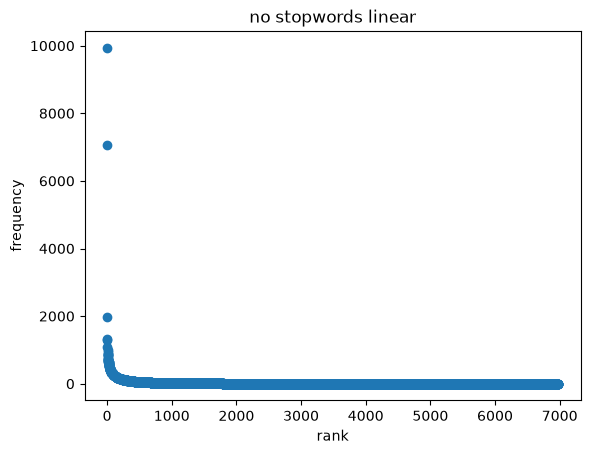

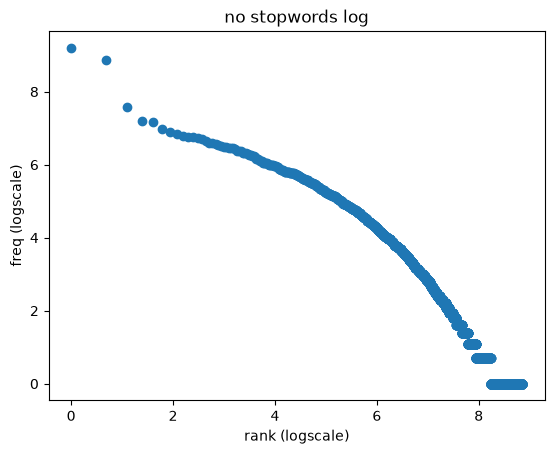

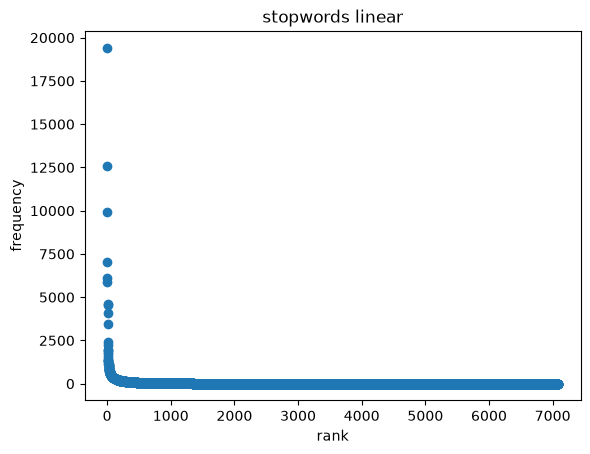

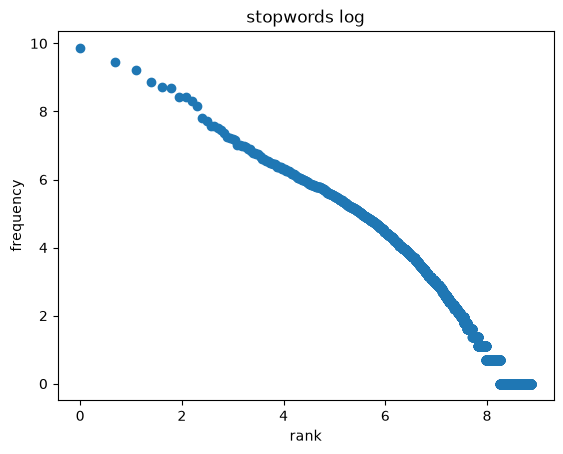

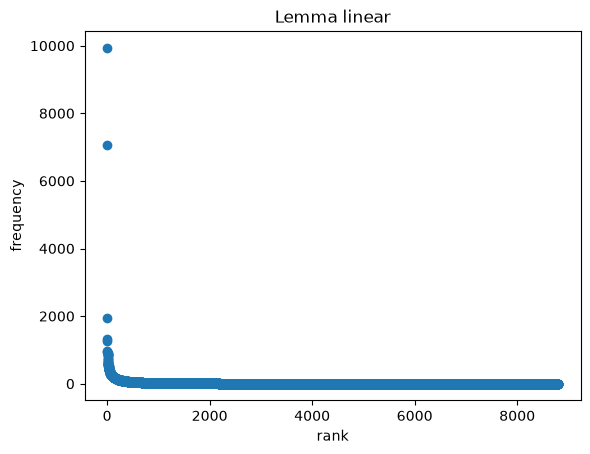

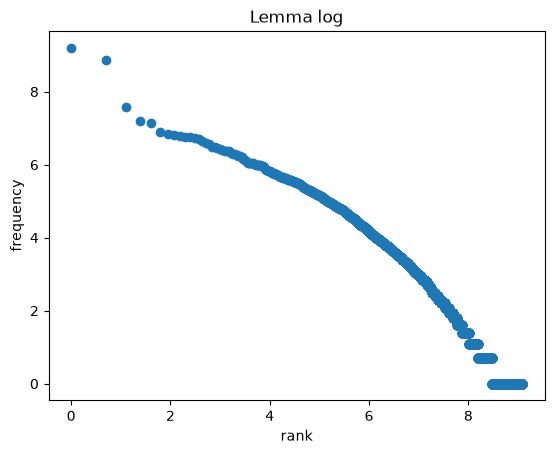

In [67]:
from collections import Counter

freq = Counter(all_tok)
freq_with_stopwords = Counter(all_tok_with_stop_words)
freq_lemma = Counter(all_tok_lemmatize)

df = pd.DataFrame(freq.most_common(), columns=["word", "frequency"])
df["rank"] = range(1, len(df) + 1)

df_stopwords = pd.DataFrame(freq_with_stopwords.most_common(), columns=["word", "frequency"])
df_stopwords["rank"] = range(1, len(df_stopwords) + 1)

df_lemma = pd.DataFrame(freq_lemma.most_common(), columns=["word", "frequency"])
df_lemma["rank"] = range(1, len(df_lemma) + 1)

df.head(10)

import matplotlib.pyplot as plt
import math

def scatter_plot(x, y, x_label, y_label, title):
    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.scatter(x, y)
    ax.set_ylabel(y_label)
    ax.set_xlabel(x_label)
    plt.show

scatter_plot(df["rank"], df["frequency"], "rank", "frequency", "no stopwords linear")

#logarithmic scale

ls = df["frequency"].apply(math.log)
ls
r_ls = df["rank"].apply(math.log)
r_ls
scatter_plot(r_ls, ls, "rank (logscale)", "freq (logscale)", "no stopwords log")


scatter_plot(df_stopwords["rank"], df_stopwords["frequency"], "rank", "frequency", "stopwords linear")
scatter_plot(df_stopwords["rank"].apply(math.log), df_stopwords["frequency"].apply(math.log), "rank", "frequency", "stopwords log")

scatter_plot(df_lemma["rank"], df_lemma["frequency"], "rank", "frequency", "Lemma linear")
scatter_plot(df_lemma["rank"].apply(math.log), df_lemma["frequency"].apply(math.log), "rank", "frequency", "Lemma log")




